=== 基本情報 ===
ノード数: 100
エッジ数: 196

=== ① 次数分布エントロピー ===
次数分布エントロピー: 1.5874594347850532
正規化エントロピー: 0.6388406723127757

=== ② 次数分布の確認 ===
次数一覧（先頭20件）: [36, 20, 6, 3, 25, 13, 10, 3, 6, 2, 7, 3, 4, 4, 2, 5, 8, 5, 4, 3]
次数ごとのノード数: {2: 51, 3: 17, 4: 11, 5: 9, 6: 4, 7: 2, 8: 1, 10: 1, 13: 1, 20: 1, 25: 1, 36: 1}
最小次数: 2
最大次数: 36
平均次数: 3.92

=== ③ このグラフの解釈 ===
Barabási–Albert モデルでは、少数の高次数ノード（ハブ）と
多数の低次数ノードができやすく、スケールフリー的な構造になりやすいです。
そのため、次数分布は均一ではなく、偏りを持ちます。

=== ④ ランダムグラフ比較 ===
ランダムグラフの p: 0.04040404040404041
BAグラフ エントロピー: 1.5874594347850532
BAグラフ 正規化エントロピー: 0.6388406723127757
ランダムグラフ エントロピー: 2.0253487583754506
ランダムグラフ 正規化エントロピー: 0.8795977896920606
→ 今回は BAグラフのほうが次数分布の偏りが強いです。

=== ⑤ ラプラシアンエントロピー ===
BAグラフ ラプラシアンエントロピー: 4.489752423728252
BAグラフ 正規化ラプラシアンエントロピー: 0.9770697109449166
ランダムグラフ ラプラシアンエントロピー: 4.424313448121621
ランダムグラフ 正規化ラプラシアンエントロピー: 0.969319881509482


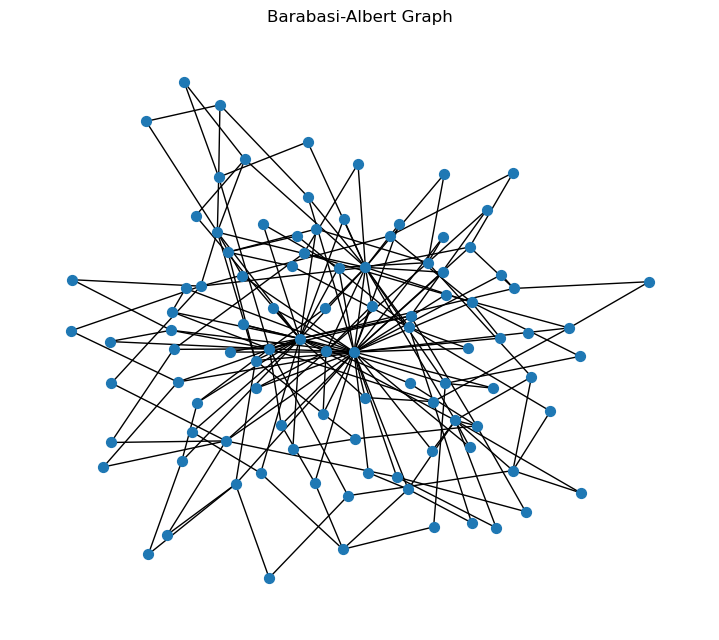

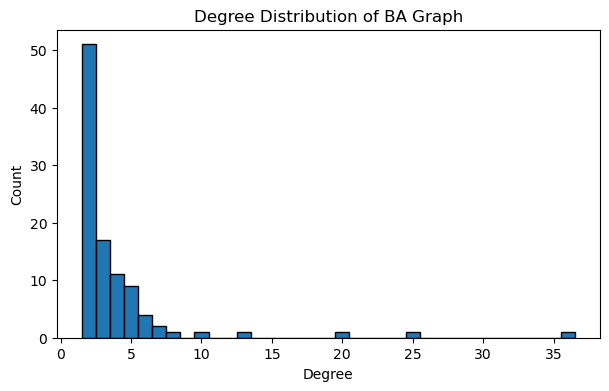

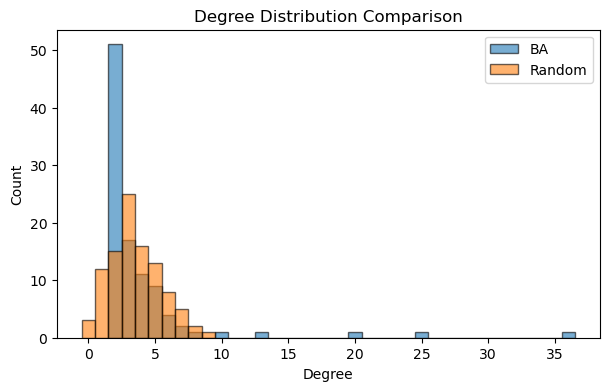

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


# =========================================
# 0. グラフ生成
# =========================================
n = 100   # ノード数
m = 2     # 新規ノードが張る辺の数

G = nx.barabasi_albert_graph(n, m, seed=42)

print("=== 基本情報 ===")
print("ノード数:", G.number_of_nodes())
print("エッジ数:", G.number_of_edges())


# =========================================
# 1. 次数分布エントロピー
# =========================================
def degree_entropy(G):
    degrees = [d for _, d in G.degree()]
    count = Counter(degrees)
    N = sum(count.values())

    p = np.array([c / N for c in count.values()], dtype=float)

    H = -np.sum(p * np.log(p))
    H_norm = H / np.log(len(p)) if len(p) > 1 else 0.0

    return H, H_norm, degrees, count


H, H_norm, degrees, degree_count = degree_entropy(G)

print("\n=== ① 次数分布エントロピー ===")
print("次数分布エントロピー:", H)
print("正規化エントロピー:", H_norm)


# =========================================
# 2. 何を測っているか確認するための出力
# =========================================
print("\n=== ② 次数分布の確認 ===")
print("次数一覧（先頭20件）:", degrees[:20])
print("次数ごとのノード数:", dict(sorted(degree_count.items())))

max_degree = max(degrees)
min_degree = min(degrees)
avg_degree = np.mean(degrees)

print("最小次数:", min_degree)
print("最大次数:", max_degree)
print("平均次数:", avg_degree)


# =========================================
# 3. このグラフの特徴の簡易説明
# =========================================
print("\n=== ③ このグラフの解釈 ===")
print("Barabási–Albert モデルでは、少数の高次数ノード（ハブ）と")
print("多数の低次数ノードができやすく、スケールフリー的な構造になりやすいです。")
print("そのため、次数分布は均一ではなく、偏りを持ちます。")


# =========================================
# 4. ランダムグラフとの比較
# =========================================
# BAグラフの平均次数はおおよそ 2m なので、
# Erdos-Renyi の p を平均次数に合わせて近づける
p_er = (2 * m) / (n - 1)

G_rand = nx.erdos_renyi_graph(n=n, p=p_er, seed=42)

H_rand, H_norm_rand, degrees_rand, degree_count_rand = degree_entropy(G_rand)

print("\n=== ④ ランダムグラフ比較 ===")
print("ランダムグラフの p:", p_er)
print("BAグラフ エントロピー:", H)
print("BAグラフ 正規化エントロピー:", H_norm)
print("ランダムグラフ エントロピー:", H_rand)
print("ランダムグラフ 正規化エントロピー:", H_norm_rand)

if H < H_rand:
    print("→ 今回は BAグラフのほうが次数分布の偏りが強いです。")
elif H > H_rand:
    print("→ 今回は ランダムグラフのほうが次数分布の偏りが強いです。")
else:
    print("→ 今回はほぼ同程度です。")


# =========================================
# 5. ラプラシアンエントロピー
# =========================================
def laplacian_entropy(G):
    L = nx.normalized_laplacian_matrix(G).toarray()
    eigvals = np.linalg.eigvals(L)
    eigvals = np.real(eigvals)

    # 0以下を除去
    eigvals = eigvals[eigvals > 1e-12]

    # そのままだと確率分布ではないので正規化
    eigvals = eigvals / np.sum(eigvals)

    H_lap = -np.sum(eigvals * np.log(eigvals))
    H_lap_norm = H_lap / np.log(len(eigvals)) if len(eigvals) > 1 else 0.0

    return H_lap, H_lap_norm, eigvals


H_lap, H_lap_norm, eigvals = laplacian_entropy(G)
H_lap_rand, H_lap_norm_rand, eigvals_rand = laplacian_entropy(G_rand)

print("\n=== ⑤ ラプラシアンエントロピー ===")
print("BAグラフ ラプラシアンエントロピー:", H_lap)
print("BAグラフ 正規化ラプラシアンエントロピー:", H_lap_norm)
print("ランダムグラフ ラプラシアンエントロピー:", H_lap_rand)
print("ランダムグラフ 正規化ラプラシアンエントロピー:", H_lap_norm_rand)


# =========================================
# 描画
# =========================================
plt.figure(figsize=(7, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=50, with_labels=False)
plt.title("Barabasi-Albert Graph")
plt.show()


# =========================================
# 次数分布のヒストグラム
# =========================================
plt.figure(figsize=(7, 4))
plt.hist(degrees, bins=range(min(degrees), max(degrees) + 2), edgecolor="black", align="left")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution of BA Graph")
plt.show()


# =========================================
# 比較用ヒストグラム
# =========================================
plt.figure(figsize=(7, 4))
plt.hist(degrees, bins=range(min(degrees), max(degrees) + 2), alpha=0.6, label="BA", edgecolor="black", align="left")
plt.hist(degrees_rand, bins=range(min(degrees_rand), max(degrees_rand) + 2), alpha=0.6, label="Random", edgecolor="black", align="left")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution Comparison")
plt.legend()
plt.show()